# Guía 5, ejercicio 5

### Importar bibliotecas

In [ ]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt

## 5.1
A partir de la definición de una máscara de filtrado pasa-altos en el dominio espacial,  obtenga la función de transferencia correspondiente a un filtro de alta potencia según $H_{AP} = (A-1) + H_{PA}$, y a un filtro de énfasis de alta frecuencia según $H_{EAF} = a + b H_{PA}$

In [ ]:
# Cargar imagen
img = cv.imread(r"C:\Users\pablo\Desktop\PDI\PDI\Imagenes\camaleon.tif", cv.IMREAD_GRAYSCALE)
M, N = img.shape

# Transformada de Fourier y desplazamiento central
F = np.fft.fft2(img)
F_shift = np.fft.fftshift(F)

# Máscara espacial pasa altos
H_PA_kernel = np.array([[-1, -1, -1],
                        [-1, 8, -1],
                        [-1, -1, -1]], dtype=np.float32)

# Aplicar mascara espacial pasa altos
img_PA_kernel = cv.filter2D(img, -1, H_PA_kernel)

# Crear filtro frecuencial del mismo tamaño que la imagen
H_padded = np.zeros_like(img, dtype=np.float32)
m, n = H_PA_kernel.shape

# Insertar el kernel en la esquina superior izquierda
H_padded[:m, :n] = H_PA_kernel

# Centrar el kernel en la imagen
H_padded = np.fft.ifftshift(H_padded)

# Transformar a dominio frecuencia
H_PA = np.fft.fft2(H_padded)
H_PA = np.fft.fftshift(H_PA)
H_PA = np.abs(H_PA)  # Magnitud del filtro
H_PA = H_PA / np.max(H_PA)  # Normalizar para que esté entre 0 y 1


### 5.2
Elija  apropiadamente  los  valores  de  los  parámetros $A$,$a$ y $b$ aplique los filtros a la imagen `'camaleon.tif'`, visualizando la imagen original junto a su TDF, y la imagen resultante con su TDF.

In [ ]:
# Parámetros para filtros
A = 1.5
a = 1
b = 1.5

# Definir filtros
H_AP = (A - 1) + H_PA
H_EAF = a + b * H_PA

# Función para aplicar filtro en frecuencia
def aplicar_filtro(F_shift, H):
    G = F_shift * H
    g = np.fft.ifft2(np.fft.ifftshift(G))
    g_real = np.real(g)
    # Normalizar para mostrar imagen
    g_norm = cv.normalize(g_real, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)
    return g_norm, G

# Aplicar filtros
img_PA, img_PA_F = aplicar_filtro(F_shift, H_PA)
img_AP, img_AP_F = aplicar_filtro(F_shift, H_AP)
img_EAF, imp_EAF_F = aplicar_filtro(F_shift, H_EAF)

def mostrar_imagen_y_espectro(img,img_F, titulo_imagen="Imagen", titulo_espectro="Espectro de Fourier"):
    magnitude_spectrum = 20 * np.log1p(np.abs(img_F))  # log(1 + |F|)

    # 4. Normalizar para visualizar con OpenCV
    magnitude_spectrum_norm = cv.normalize(magnitude_spectrum, None, 0, 255, cv.NORM_MINMAX)
    magnitude_spectrum_uint8 = magnitude_spectrum_norm.astype(np.uint8)

    # 5. Concatenar lado a lado (ambas deben ser del mismo tipo y tamaño)
    combined = np.hstack((img, magnitude_spectrum_uint8))

    # 6. Mostrar con OpenCV
    cv.imshow(titulo_imagen+" "+titulo_espectro,combined)

# Mostrar resultados
mostrar_imagen_y_espectro(img, F_shift, "Imagen Original", "Espectro de Fourier Original")
mostrar_imagen_y_espectro(img_PA, img_PA_F, "Imagen con Filtro Pasa Altos", "Espectro de Fourier Pasa Altos")
mostrar_imagen_y_espectro(img_AP, img_AP_F, "Imagen con Filtro Alta potencia", "Espectro de Fourier Alta potencia")
mostrar_imagen_y_espectro(img_EAF, imp_EAF_F, "Imagen con Filtro EAF", "Espectro de Fourier EAF")

### 5.3
Compare la imagen de alta potencia con la que se obtiene al aplicar el filtro en el dominio espacial.

In [ ]:
# Mostrar imagen con opencv
def mostrar_imagen(img, titulo="Imagen"):
    cv.imshow(titulo, img)

mostrar_imagen(img_PA_kernel)

plt.show()
cv.waitKey(0)
cv.destroyAllWindows()

# Guía 5, ejercicio 6.2
Realice una aplicació  de preprocesamiento para OCR. La imagen de entrada es un texto escaneado (puede utilizar `parrafo0.jpg` y `parrafo1.jpg`), usted debe identificar si el texto está rotado y de ser así, debe corregir la orientación del texto.

### Planteo de solución
- Se mostrará en pantalla la imagen y el espectro de su transformada.
- El usuario debe identificar la línea más preponderante en el espectro de la transformada, correspondiente a la orientación del texto.
- En base a esta línea, se calcula el ángulo de rotación y se corrige la imagen original.

### Importar bibliotecas

In [ ]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt
from numpy.fft import fft2, fftshift

### Manejo de los eventos del mouse

In [ ]:
# Variables para guardar los puntos detectados
punto_A = None
punto_B = None
angulo = None

# Función que maneja los eventos del mouse
def seleccionar_puntos(event, x, y, flags, param):
    global punto_A, punto_B, angulo

    if event == cv.EVENT_LBUTTONDOWN:
        if punto_A is None:
            punto_A = (x, y)
        else:
            if punto_B is None:
                punto_B = (x, y)
            else:
                punto_A = punto_B
                punto_B = (x, y)

        print(f"Clic en: ({x}, {y})")
        print(f"Angulo {angulo}")

### Manejo de imagen y su espectro

In [ ]:
# Cargar imagen
img = cv.imread('imagenes/parrafo1.jpg', cv.IMREAD_GRAYSCALE)

# Calcular Espectro
F = fft2(img)
F_shifted = fftshift(F)
magnitude = np.abs(F_shifted)
spectrum = np.log1p(magnitude)
spectrum_norm = cv.normalize(spectrum, None, 0, 255, cv.NORM_MINMAX)
spectrum_uint8 = spectrum_norm.astype(np.uint8)

### Manejo de ventanas y captura de clicks

In [ ]:
cv.namedWindow("Texto")
cv.namedWindow("Seleccionar 2 puntos")
cv.setMouseCallback("Seleccionar 2 puntos", seleccionar_puntos)

while True:
    # Dibujar los puntos si fueron seleccionados
    size = 512
    img_mostrar = cv.resize(spectrum_uint8.copy(), (size, size), interpolation=cv.INTER_NEAREST)
    
    img_rotada = img.copy()

    # Dibujar los puntos y la línea que los une
    if punto_A != None:
        cv.circle(img_mostrar, punto_A, 5, (0, 0, 255), -1)
    if punto_B != None:
        cv.circle(img_mostrar, punto_B, 5, (0, 0, 255), -1)
        cv.line(img_mostrar,punto_A,punto_B,color=(0,0,255))
        
    # Calcular el ángulo en grados entre A y B respecto al eje horizontal
        dx = punto_B[0] - punto_A[0]
        dy = punto_B[1] - punto_A[1]
        angulo = np.degrees(np.arctan2(dx, dy))

    # Rotar la imagen según el ángulo calculado
    if angulo != None:
        (h, w) = img.shape[:2]
        center = (w // 2, h // 2)
        M = cv.getRotationMatrix2D(center, -angulo, 1.0)
        img_rotada = cv.warpAffine(img.copy(), M, (w, h))

    # Mostrar la imagen original rotada y el espectro de la original
    cv.imshow("Texto",img_rotada)
    cv.imshow("Seleccionar 2 puntos", img_mostrar)

    key = cv.waitKey(1) & 0xFF
    # Presionar ESC para salir
    if key == 27:
        break

# Liberar recursos
cv.destroyAllWindows()

# GUIA RESTAURACION EJERCICIO 3



ECM de mayor a menor:
Filtro Punto Medio: 1026.82
Filtro Mediana + Punto Medio: 259.82
Filtro Mediana: 134.90
Filtro MediaAlfaRecortado: 49.12


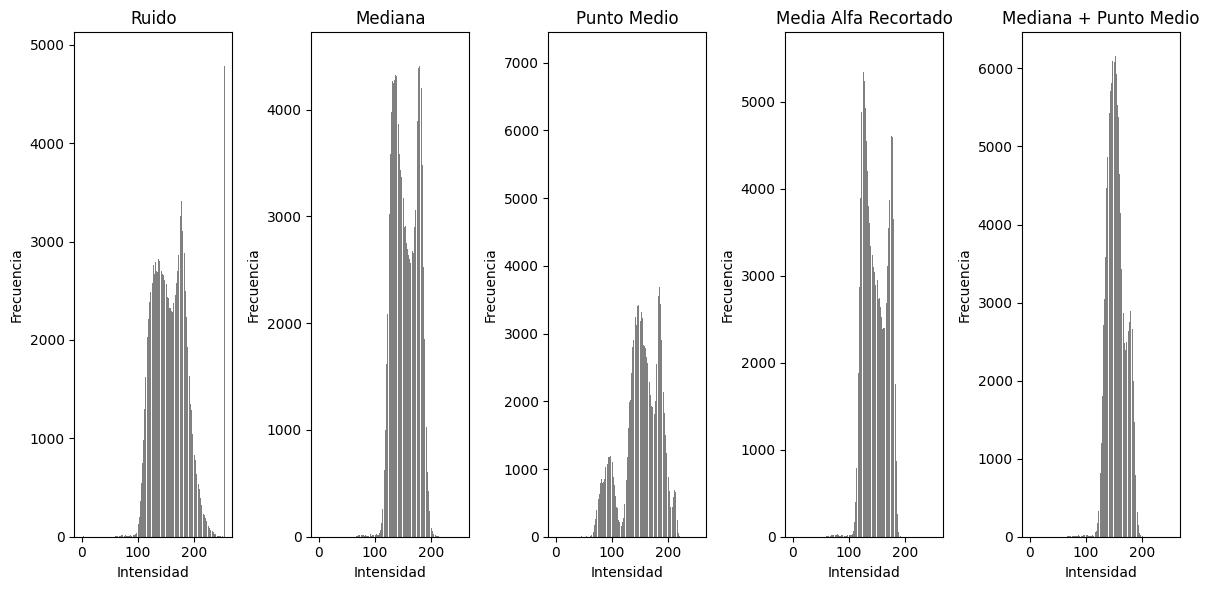

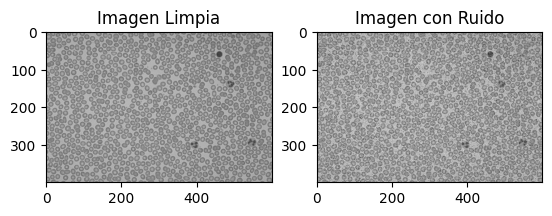

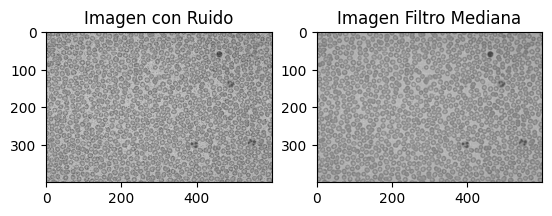

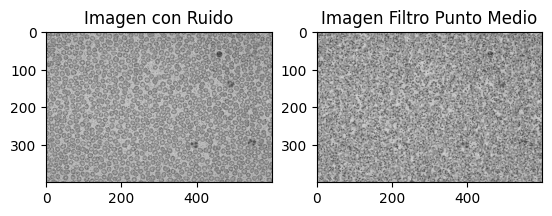

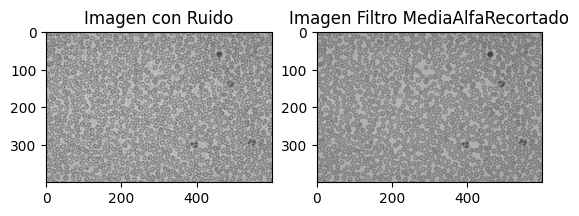

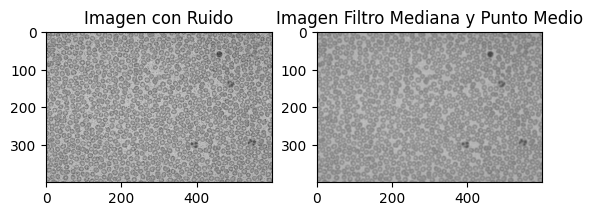

'\nEl filtro de media geométrica no es adecuado para la imagen degradada con sal y pimienta, ya que el ruido impulsivo introduce ceros que inutilizan la media.\n\nEl filtro de media contra-armónica puede ser útil si se ajusta correctamente Q, pero no es robusto frente a una mezcla de sal y pimienta como la que se simuló.\n\nLa media alfa-recortada se posiciona como la opción más versátil, ya que no requiere conocer el tipo específico de ruido y funciona bien con ruido mixto.\n\n'

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from ej1_1 import ruido_exp
from ej1_1 import ruido_sp

def filtro_mediana(img,s,t): #Buena reducción de ruido impulsivo sin el desenfoque de un filtro lineal de la misma talla.
    img_sauv = np.zeros_like(img)
    pad_s = s // 2
    pad_t = t // 2
    padded = cv.copyMakeBorder(img, pad_s, pad_s, pad_t, pad_t, cv.BORDER_REPLICATE)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            valores = []
            for m in range(-pad_s, pad_s + 1):
                for n in range(-pad_t, pad_t + 1):
                    valores.append(padded[i + pad_s + m, j + pad_t + n])
            mediana = np.median(valores)
            img_sauv[i, j] = mediana
    return img_sauv

def filtro_puntomedio(img,s,t):#Util para ruido tipo gaussiano o uniforme.
    img_sauv = np.zeros_like(img, dtype=np.float32)
    pad_s = s // 2
    pad_t = t // 2
    padded = cv.copyMakeBorder(img, pad_s, pad_s, pad_t, pad_t, cv.BORDER_REPLICATE)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            valores = []
            for m in range(-pad_s, pad_s + 1):
                for n in range(-pad_t, pad_t + 1):
                    valores.append(padded[i + pad_s + m, j + pad_t + n])
            img_sauv[i, j] = 0.5 * (float(min(valores)) + float(max(valores)))
    return np.clip(img_sauv, 0, 255).astype(np.uint8)

#Util para combinaciones de ruido gaussiano y sal y pimienta.
def filtro_MediaAlfaRecortado(img, d, s, t):
    img_sauv = np.zeros_like(img, dtype=np.float32)
    pad_s = s // 2
    pad_t = t // 2
    padded = cv.copyMakeBorder(img, pad_s, pad_s, pad_t, pad_t, cv.BORDER_REPLICATE)
    
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            valores = []
            for m in range(-pad_s, pad_s + 1):
                for n in range(-pad_t, pad_t + 1):
                    valor = float(padded[i + pad_s + m, j + pad_t + n])
                    valores.append(valor)
            valores.sort()
            d = min(d, len(valores) - 1)  # Evitar que d sea mayor que la cantidad de píxeles
            recorte = d // 2
            valores_recortados = valores[recorte:len(valores)-recorte]
            if len(valores_recortados) > 0:
                media = sum(valores_recortados) / len(valores_recortados)
            else:
                media = valores[len(valores) // 2]  # fallback
            img_sauv[i, j] = media
    
    return np.clip(img_sauv, 0, 255).astype(np.uint8)

def mse(imageA, imageB):
    err = np.sum((imageA.astype("float") - imageB.astype("float")) ** 2)
    err /= float(imageA.shape[0] * imageA.shape[1])
    return err
# Función para graficar histogramas
def graficar_histogramas(imagenes, titulos, fig_num):
    plt.figure(fig_num, figsize=(12, 6))
    for i, img in enumerate(imagenes):
        plt.subplot(1, len(imagenes), i+1)
        histima = cv.calcHist([img], [0], None, [256], [0, 256])
        plt.bar(range(256), histima.ravel(), color='gray')
        plt.title(titulos[i])
        plt.xlabel('Intensidad')
        plt.ylabel('Frecuencia')
    plt.tight_layout()

if __name__ == "__main__":
    img_sangre = cv.imread(r'C:\Users\pablo\Desktop\PDI\PDI\Imagenes\sangre.jpg',cv.IMREAD_GRAYSCALE)

    ruido_gauss = cv.randn( np.zeros(img_sangre.shape, dtype=np.uint8) , 0, 20)
    img_sangre_ruido = img_sangre + ruido_gauss
    img_sangre_ruido = ruido_sp(img_sangre_ruido.copy(), 0.02, 0.02, 255, 0)

    img_mediana = filtro_mediana(img_sangre_ruido,3,3)
    img_punto_medio = filtro_puntomedio(img_sangre_ruido,3,3)
    img_mediaalfarecor = filtro_MediaAlfaRecortado(img_sangre,4,3,3)
    img_mediana_puntomedio = filtro_puntomedio(img_mediana,3,3)

    ecm_mediana = mse(img_sangre, img_mediana)
    ecm_puntomedio = mse(img_sangre, img_punto_medio)
    ecm_alfarecortado = mse(img_sangre, img_mediaalfarecor)
    ecm_medianapuntomedio = mse(img_sangre, img_mediana_puntomedio)
    ecms = [
        ("Filtro Mediana", ecm_mediana),
        ("Filtro Punto Medio", ecm_puntomedio),
        ("Filtro MediaAlfaRecortado", ecm_alfarecortado),
        ("Filtro Mediana + Punto Medio", ecm_medianapuntomedio)
    ]

    ecms_sorted = sorted(ecms, key=lambda x: x[1], reverse=True)

    graficar_histogramas(
    [img_sangre_ruido, img_mediana, img_punto_medio, img_mediaalfarecor, img_mediana_puntomedio],
    ["Ruido", "Mediana", "Punto Medio", "Media Alfa Recortado", "Mediana + Punto Medio"],
    fig_num=6
    )

    print("ECM de mayor a menor:")
    for nombre, valor in ecms_sorted:
        print(f"{nombre}: {valor:.2f}")

    plt.figure(1)
    plt.subplot(1, 2, 1)
    plt.imshow(img_sangre, cmap='gray', vmin=0, vmax=255)
    plt.title('Imagen Limpia')
    plt.subplot(1, 2, 2)
    plt.imshow(img_sangre_ruido, cmap='gray', vmin=0, vmax=255)
    plt.title('Imagen con Ruido')

    plt.figure(2)
    plt.subplot(1, 2, 1)
    plt.imshow(img_sangre_ruido, cmap='gray', vmin=0, vmax=255)
    plt.title('Imagen con Ruido')
    plt.subplot(1, 2, 2)
    plt.imshow(img_mediana, cmap='gray', vmin=0, vmax=255)
    plt.title('Imagen Filtro Mediana')

    plt.figure(3)
    plt.subplot(1, 2, 1)
    plt.imshow(img_sangre_ruido, cmap='gray', vmin=0, vmax=255)
    plt.title('Imagen con Ruido')
    plt.subplot(1, 2, 2)
    plt.imshow(img_punto_medio, cmap='gray', vmin=0, vmax=255)
    plt.title('Imagen Filtro Punto Medio')

    plt.figure(4)
    plt.subplot(1, 2, 1)
    plt.imshow(img_sangre_ruido, cmap='gray', vmin=0, vmax=255)
    plt.title('Imagen con Ruido')
    plt.subplot(1, 2, 2)
    plt.imshow(img_mediaalfarecor, cmap='gray', vmin=0, vmax=255)
    plt.title('Imagen Filtro MediaAlfaRecortado')

    plt.figure(5)
    plt.subplot(1, 2, 1)
    plt.imshow(img_sangre_ruido, cmap='gray', vmin=0, vmax=255)
    plt.title('Imagen con Ruido')
    plt.subplot(1, 2, 2)
    plt.imshow(img_mediana_puntomedio, cmap='gray', vmin=0, vmax=255)
    plt.title('Imagen Filtro Mediana y Punto Medio')
    plt.show()

'''
Comparación cuantitativa (Error Cuadrático Medio - ECM):
ECM de mayor a menor:
Filtro Punto Medio: 1031.85
Filtro Mediana + Punto Medio: 260.37
Filtro Mediana: 135.57
Filtro MediaAlfaRecortado: 49.12

El filtro Media Alfa Recortado presenta el menor ECM, seguido de cerca la combinación Mediana 

2. Comparación cualitativa (subjetiva)
Filtro de Mediana: Elimina eficazmente el ruido impulsivo (sal y pimienta) sin generar tanto desenfoque como un filtro lineal. Sin embargo, es menos eficaz ante el ruido gaussiano, lo que puede dejar un grano visible en zonas homogéneas.

Filtro del Punto Medio: Promedia entre el mínimo y el máximo valor de la vecindad. Es adecuado para ruido gaussiano, pero poco eficaz contra ruido impulsivo, ya que puede verse afectado por los valores extremos (salt and pepper).

Filtro de Media Alfa Recortado: Elimina los valores extremos de la vecindad antes de calcular la media. Esto permite filtrar simultáneamente el ruido impulsivo y el gaussiano de forma balanceada. El resultado es más suave y cercano a la imagen original, sin tanto desenfoque ni artefactos visibles.

Mediana + Punto Medio: Primero elimina el ruido impulsivo y luego suaviza el ruido gaussiano restante. Esta combinación es efectiva, con resultados visuales satisfactorios y bajo ECM, aunque puede implicar un mayor costo computacional.

3. Observación de los histogramas
Los histogramas muestran cómo cada filtro afecta la distribución de niveles de gris:

El filtro de Mediana tiende a conservar la forma del histograma original pero reduciendo los picos extremos (valores 0 y 255).

El Punto Medio produce una concentración mayor en los valores medios, lo que sugiere un efecto suavizador.

El Media Alfa Recortado mantiene una distribución más balanceada, eliminando valores extremos y acercándose a la distribución original.

La combinación Mediana + Punto Medio aplana aún más los extremos y reduce la varianza del histograma, similar al efecto de un suavizado moderado.
'''
'''
El filtro de media geométrica no es adecuado para la imagen degradada con sal y pimienta, ya que el ruido impulsivo introduce ceros que inutilizan la media.

El filtro de media contra-armónica puede ser útil si se ajusta correctamente Q, pero no es robusto frente a una mezcla de sal y pimienta como la que se simuló.

La media alfa-recortada se posiciona como la opción más versátil, ya que no requiere conocer el tipo específico de ruido y funciona bien con ruido mixto.

'''

# EJERCICIO 7

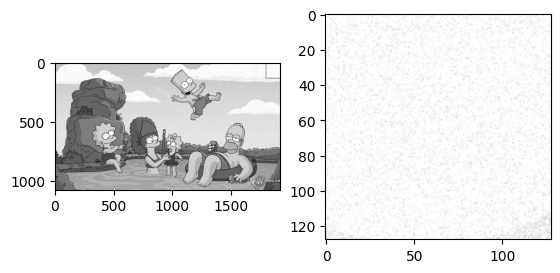

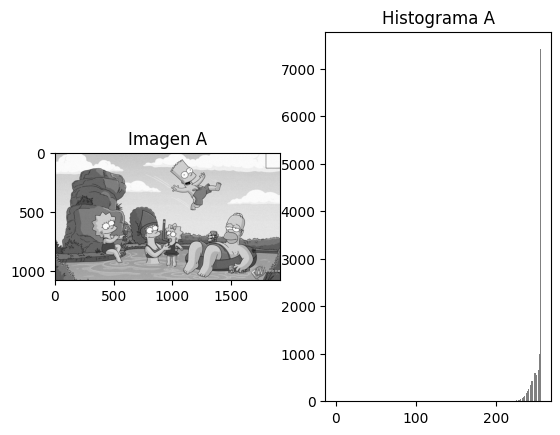

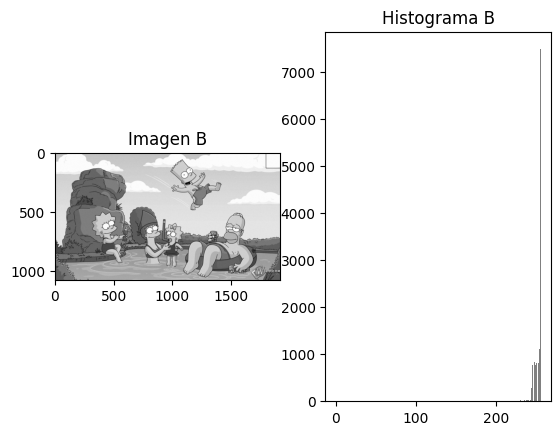

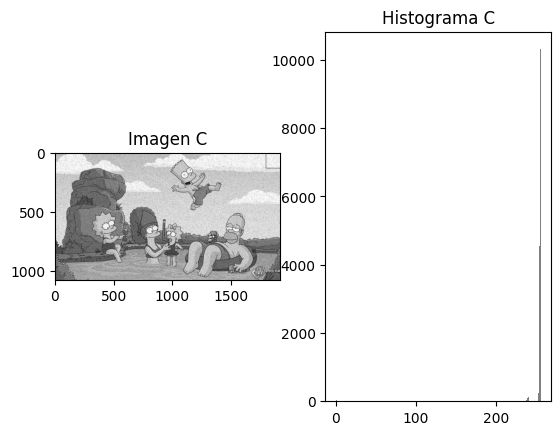

Media estimada de A: 250.2379150390625
Varianza estimada de A: 41.63895307481289
Desvio estimado de A: 6.452825201011793
Media estimada de B: 241.5
Varianza estimada de B: 60.75
Pico de pimienta (intensidad baja): 0
Pico de sal (intensidad alta): 255
Probabilidad de 0 (Pa): 0.05340576171875
Probabilidad de 255 (Pb): 0.62939453125


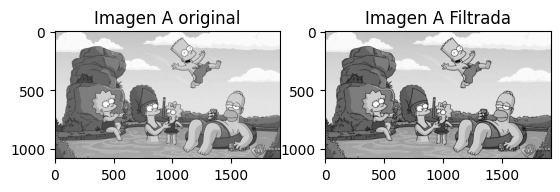

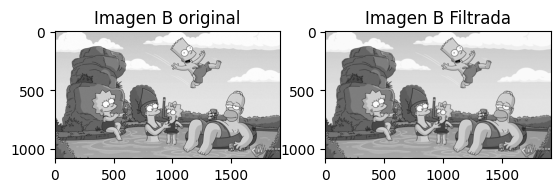

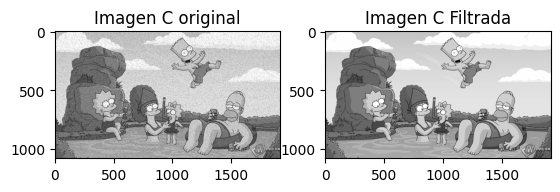

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from ej2_1 import *
from ej3_1 import *

def encontrar_bloque_mas_homogeneo(img, block_size=32):
    #Inizializar varianza en un valor muy alto y el bloque más homogéneo en (0, 0).
    min_var = float('inf')
    mejor_bloque = (0, 0)
    for y in range(0, img.shape[0] - block_size + 1, block_size):
        for x in range(0, img.shape[1] - block_size + 1, block_size):
            #Extraer el bloque y calcular su varianza.
            bloque = img[y:y+block_size, x:x+block_size]
            var = np.var(bloque)
            #Si la varianza del bloque es menor que la mínima encontrada, actualizar el bloque más homogéneo.
            if var < min_var:
                min_var = var
                mejor_bloque = (x, y)
    return mejor_bloque, block_size

#Leer imagenes
img_a = cv.imread(r'C:\Users\pablo\Desktop\PDI\PDI\Imagenes\FAMILIA_a.jpg',cv.IMREAD_GRAYSCALE)
img_b = cv.imread(r'C:\Users\pablo\Desktop\PDI\PDI\Imagenes\FAMILIA_b.jpg',cv.IMREAD_GRAYSCALE)
img_c = cv.imread(r'C:\Users\pablo\Desktop\PDI\PDI\Imagenes\FAMILIA_c.jpg',cv.IMREAD_GRAYSCALE)
#Recortar áreas constantes en imágenes adquiridas.
(x, y), block_size = encontrar_bloque_mas_homogeneo(img_a, block_size=128)
#Extraer bloques homogéneos de las imágenes.
bloque_a = img_a[y:y+block_size, x:x+block_size]
bloque_b = img_b[y:y+block_size, x:x+block_size]
bloque_c = img_c[y:y+block_size, x:x+block_size]
#Dibujar rectángulos en las imágenes originales para mostrar el área homogénea.
img_a_recthomogeneo =cv.rectangle(img_a.copy(),(x,y),(x+block_size,y+block_size),(0,0,0),2)
img_b_recthomogeneo =cv.rectangle(img_b.copy(),(x,y),(x+block_size,y+block_size),(0,0,0),2)
img_c_recthomogeneo =cv.rectangle(img_c.copy(),(x,y),(x+block_size,y+block_size),(0,0,0),2)

plt.figure(0)
plt.subplot(121)
plt.imshow(img_a_recthomogeneo, cmap='gray', vmin=0, vmax=255)
plt.subplot(122)
plt.imshow(bloque_a, cmap='gray', vmin=0, vmax=255)
hist_a = cv.calcHist([bloque_a], [0], None, [256], [0, 256])
hist_b = cv.calcHist([bloque_b], [0], None, [256], [0, 256])
hist_c = cv.calcHist([bloque_c], [0], None, [256], [0, 256])

plt.figure(1)
plt.subplot(121)
plt.imshow(img_a_recthomogeneo, cmap='gray', vmin=0, vmax=255)
plt.title('Imagen A')
plt.subplot(122)
plt.bar(range(256), hist_a.ravel(), color='gray')
plt.title('Histograma A')

plt.figure(2)
plt.subplot(121)
plt.imshow(img_b_recthomogeneo, cmap='gray', vmin=0, vmax=255)
plt.title('Imagen B')
plt.subplot(122)
plt.bar(range(256), hist_b.ravel(), color='gray')
plt.title('Histograma B')

plt.figure(3)
plt.subplot(121)
plt.imshow(img_c_recthomogeneo, cmap='gray', vmin=0, vmax=255)
plt.title('Imagen C')
plt.subplot(122)
plt.bar(range(256), hist_c.ravel(), color='gray')
plt.title('Histograma C')
plt.show()
#Por observacion de los histogramas de las areas mas homogeneas de la imagenes se puede ver que:
# -La imagen A tiene un ruido gaussiano aditivo, ya que se forma una campana de gauss al rededor del pico
# -La imagen B tiene un ruido uniforme, ya que el histograma es plano y no tiene picos definidos
# -La imagen C tiene un ruido de sal y pimienta, ya que el histograma tiene picos en los extremos (0 y 255)

#calcular los parametros estadisticos para dichos ruidos
media_a = np.mean(bloque_a)
varianza_a = np.var(bloque_a)
desvio_a = np.std(bloque_a)
print(f"Media estimada de A: {media_a}")
#El desvío estándar es la raíz cuadrada de la varianza. Ambos describen la dispersión del ruido gaussiano, pero el desvío estándar está en las mismas unidades que la imagen.
print(f"Varianza estimada de A: {varianza_a}")
print(f"Desvio estimado de A: {desvio_a}")

a = float(bloque_b.min())
b = float(bloque_b.max())
media_b = (a + b) / 2.0
varianza_b = ((b - a) ** 2.0) / 12.0
print(f"Media estimada de B: {media_b}")
print(f"Varianza estimada de B: {varianza_b}")

#Analizar si la sal y pimienta son 0 y 255 en el histograma
# Rango de búsqueda para pimienta y sal (ajusta según tu caso)
rango_pimienta = hist_c[:30]   # Intensidades bajas
rango_sal = hist_c[225:]       # Intensidades altas

# Índices de los máximos en cada rango
pico_pimienta = np.argmax(rango_pimienta)
pico_sal = 225 + np.argmax(rango_sal)

print(f"Pico de pimienta (intensidad baja): {pico_pimienta}")
print(f"Pico de sal (intensidad alta): {pico_sal}")

total = bloque_c.size
Pa = np.sum(bloque_c == pico_pimienta) / total
Pb = np.sum(bloque_c == pico_sal) / total
print(f"Probabilidad de 0 (Pa): {Pa}")
print(f"Probabilidad de 255 (Pb): {Pb}")

#Elegir los filtros mas adecuados para cada tipo de ruido
#Para el rudio gaussiano usar filtro de media geometrica o armonica
#Para el ruido uniforme usar filtro de puntomedio
#Para el ruido de sal y pimienta usar filtro de mediana

img_a_filtrada = filtro_media_geom_log(img_a,3,3)
#img_a_filtrada = filtro_contraarmonica(img_a,-1,3,3)
img_b_filtrada = filtro_puntomedio(img_b,3,3)
#img_c_filtrada = filtro_mediana(img_c,3,3)
img_c_filtrada = cv.medianBlur(img_c,3)

plt.figure(1)
plt.subplot(121)
plt.imshow(img_a, cmap='gray', vmin=0, vmax=255)
plt.title('Imagen A original')
plt.subplot(122)
plt.imshow(img_a_filtrada, cmap='gray', vmin=0, vmax=255)
plt.title('Imagen A Filtrada')

plt.figure(2)
plt.subplot(121)
plt.imshow(img_b, cmap='gray', vmin=0, vmax=255)
plt.title('Imagen B original')
plt.subplot(122)
plt.imshow(img_b_filtrada, cmap='gray', vmin=0, vmax=255)
plt.title('Imagen B Filtrada')

plt.figure(3)
plt.subplot(121)
plt.imshow(img_c, cmap='gray', vmin=0, vmax=255)
plt.title('Imagen C original')
plt.subplot(122)
plt.imshow(img_c_filtrada, cmap='gray', vmin=0, vmax=255)
plt.title('Imagen C Filtrada')
plt.show()


# Guia segmentacion ejercicio 1.5

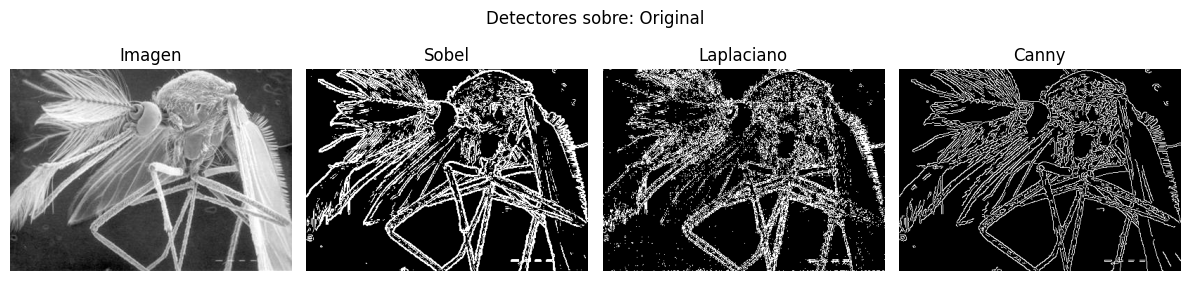

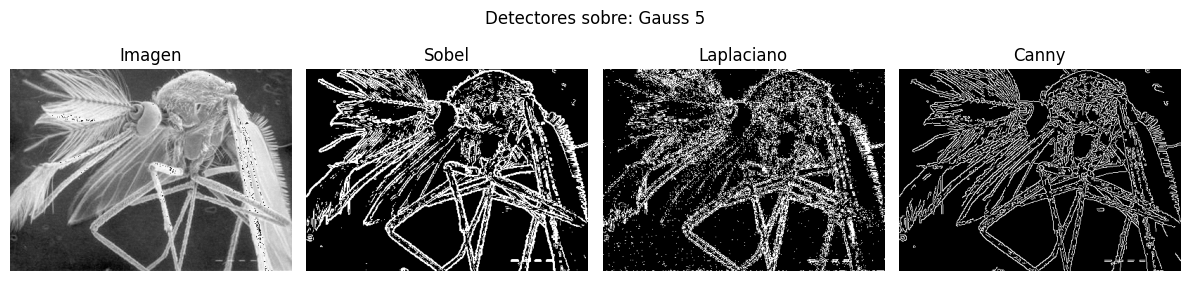

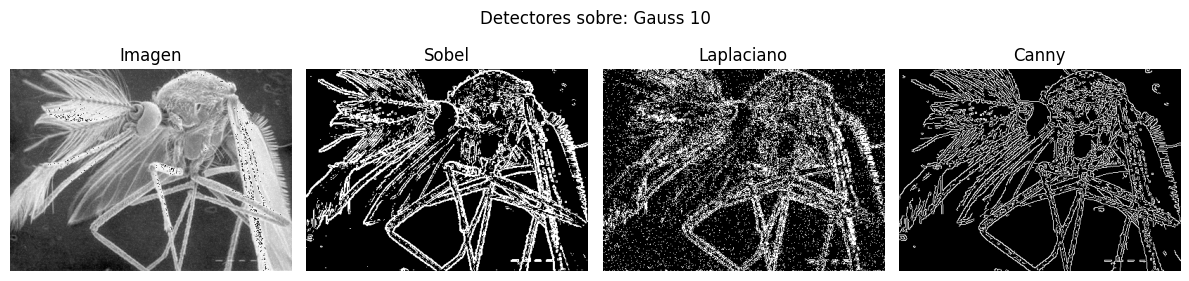

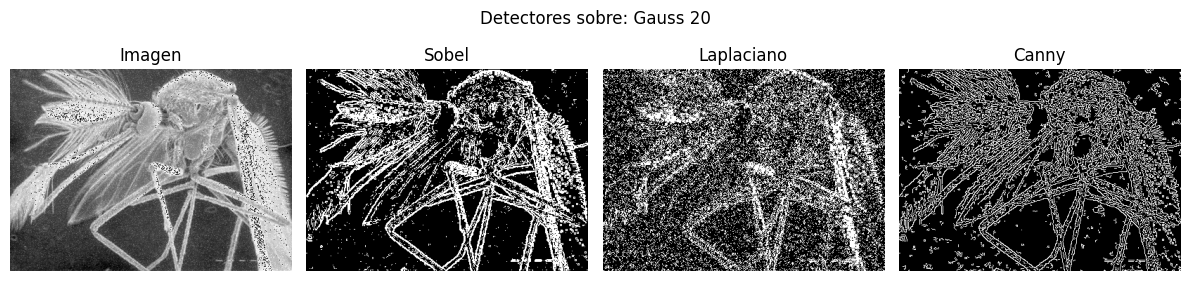

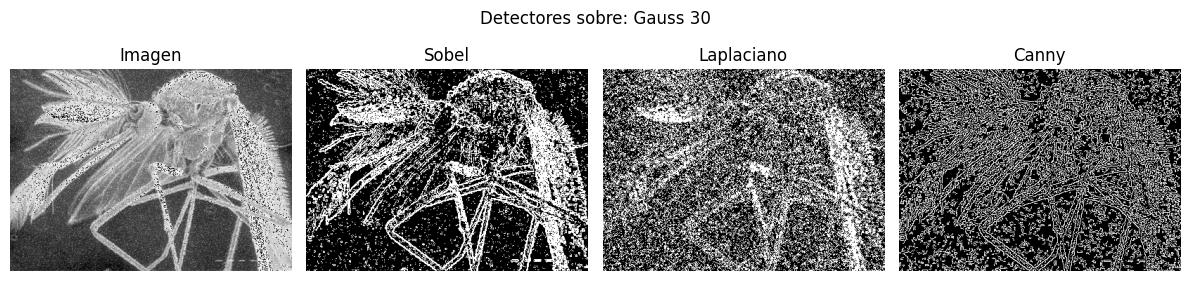

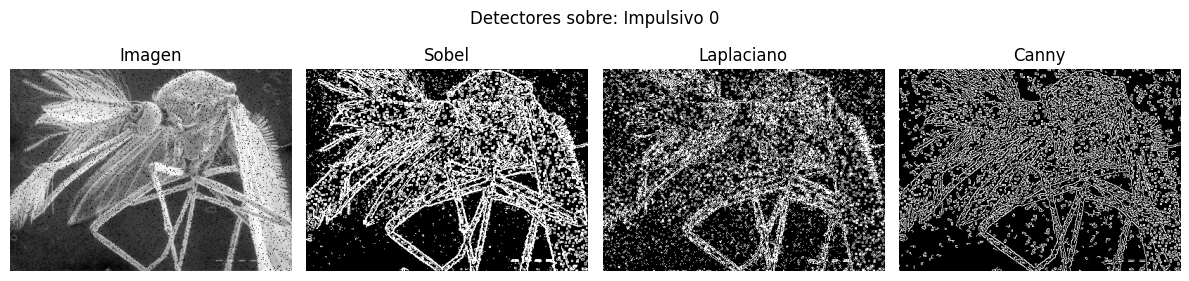

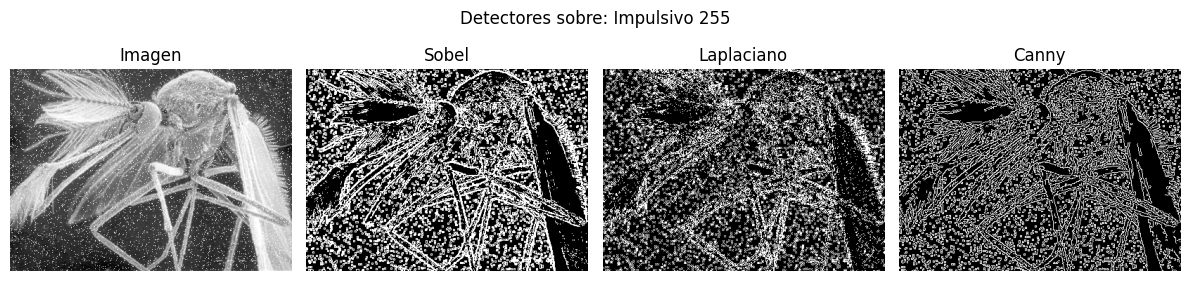

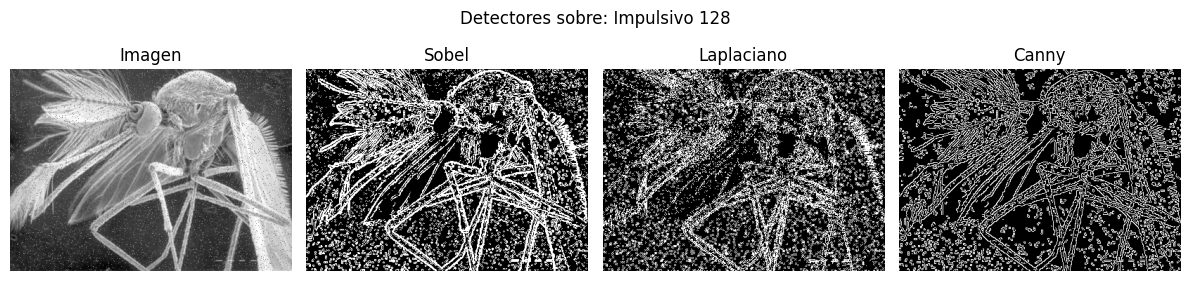

'\n**Comparación:**  \n- **Sobel**: sensible al ruido, especialmente al impulsivo.\n- **Laplaciano**: muy sensible al ruido, resalta mucho el ruido impulsivo y gaussiano.\n- **Canny**: más robusto, suele dar mejores resultados en presencia de ruido, pero puede perder bordes si el ruido es muy fuerte.\n\n¿En qué zonas funciona mejor cada método y por qué?\nSobel:\nFunciona bien en zonas con cambios de intensidad suaves y bordes bien definidos. Es bueno para detectar bordes orientados en X o Y,\n pero puede perder detalles en bordes diagonales o muy finos.\nLaplaciano:\nDetecta bordes en todas las direcciones y es muy sensible a cambios bruscos de \nintensidad. Resalta detalles finos, pero también responde mucho al ruido y a texturas pequeñas.\nCanny:\nEs el más robusto. Funciona mejor en zonas donde los bordes son claros y continuos,\nya que incluye supresión de no-máximos y umbralización doble. Puede perder bordes muy débiles, pero reduce la detección de falsos bordes.\n\nQué sucede co

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def ruido_sp(img, probs, probp, valors, valorp):
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            r = np.random.rand()
            if r < probp:
                img[i, j] = valorp
            elif r < probs + probp:
                img[i, j] = valors
    return img

img = cv.imread(r'C:\Users\pablo\Desktop\PDI\PDI\Imagenes\mosquito.jpg',cv.IMREAD_GRAYSCALE)

gauss_20 = cv.randn(img.copy(), 0, 20)
gauss_20 = img + gauss_20
gauss_30 = cv.randn(img.copy(), 0, 30)
gauss_30 = img + gauss_30
gauss_10 = cv.randn(img.copy(), 0, 10)
gauss_10 = img + gauss_10
gauss_5 = cv.randn(img.copy(), 0, 5)
gauss_5 = img + gauss_5

impulsivo_0 = ruido_sp(img.copy(), 0, 0.05, 0, 0)      
impulsivo_255 = ruido_sp(img.copy(), 0.05, 0, 255, 0) 
impulsivo_128 = ruido_sp(img.copy(), 0.05, 0, 128, 0)  # gris medio
imagenes = [
    ("Original", img),
    ("Gauss 5", gauss_5),
    ("Gauss 10", gauss_10),
    ("Gauss 20", gauss_20),
    ("Gauss 30", gauss_30),
    ("Impulsivo 0", impulsivo_0),
    ("Impulsivo 255", impulsivo_255),
    ("Impulsivo 128", impulsivo_128)
]

def aplicar_detectores(imagen):
    # Sobel
    sobelx = cv.Sobel(imagen, cv.CV_64F, 1, 0, ksize=3)
    sobely = cv.Sobel(imagen, cv.CV_64F, 0, 1, ksize=3)
    sobel = cv.magnitude(sobelx, sobely)
    sobel = np.abs(sobel)
    sobel = np.uint8(np.clip(np.abs(sobel), 0, 255))
    #_, resultado = cv.threshold(resultado, 30, 255, cv.THRESH_BINARY)
    _, sobel = cv.threshold(sobel, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
            
    # Laplaciano
    lap = cv.Laplacian(imagen, cv.CV_64F, ksize=3)
    lap_abs = np.abs(lap)
    lap_uint8 = np.uint8(np.clip(lap_abs, 0, 255))
    _, lap_bin = cv.threshold(lap_uint8, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
    
    # Canny
    canny = cv.Canny(imagen, 100, 200)
    return sobel, lap_bin, canny

# Mostrar resultados
for nombre, im in imagenes:
    sobel, lap, canny = aplicar_detectores(im)
    plt.figure(figsize=(12, 3))
    plt.suptitle(f"Detectores sobre: {nombre}")
    plt.subplot(1, 4, 1)
    plt.imshow(im, cmap='gray')
    plt.title("Imagen")
    plt.axis('off')
    plt.subplot(1, 4, 2)
    plt.imshow(sobel, cmap='gray')
    plt.title("Sobel")
    plt.axis('off')
    plt.subplot(1, 4, 3)
    plt.imshow(lap, cmap='gray')
    plt.title("Laplaciano")
    plt.axis('off')
    plt.subplot(1, 4, 4)
    plt.imshow(canny, cmap='gray')
    plt.title("Canny")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

'''
**Comparación:**  
- **Sobel**: sensible al ruido, especialmente al impulsivo.
- **Laplaciano**: muy sensible al ruido, resalta mucho el ruido impulsivo y gaussiano.
- **Canny**: más robusto, suele dar mejores resultados en presencia de ruido, pero puede perder bordes si el ruido es muy fuerte.

¿En qué zonas funciona mejor cada método y por qué?
Sobel:
Funciona bien en zonas con cambios de intensidad suaves y bordes bien definidos. Es bueno para detectar bordes orientados en X o Y,
 pero puede perder detalles en bordes diagonales o muy finos.
Laplaciano:
Detecta bordes en todas las direcciones y es muy sensible a cambios bruscos de 
intensidad. Resalta detalles finos, pero también responde mucho al ruido y a texturas pequeñas.
Canny:
Es el más robusto. Funciona mejor en zonas donde los bordes son claros y continuos,
ya que incluye supresión de no-máximos y umbralización doble. Puede perder bordes muy débiles, pero reduce la detección de falsos bordes.

Qué sucede con el ruido?
Sobel:
El ruido, especialmente el impulsivo, genera muchos falsos bordes. 
El método es sensible al ruido porque calcula derivadas locales.
Enfatiza los píxeles más cercanos al centro, consiguiendo una mejor
respuesta en presencia de ruido tipo gaussiano.
Laplaciano:
Es el más sensible al ruido de los tres. El ruido, tanto gaussiano como impulsivo, se amplifica mucho y aparecen muchos bordes falsos.
 Excesivamente sensible al ruido.
 Produce bordes dobles.
 No detecta dirección de los bordes.
 Se requiere determinar los cruces por cero.
 Su utilidad se limita a clasificar los puntos que pertenecen a la zona clara y a la zona
 oscura a cada lado del borde
Canny:
Es el más robusto frente al ruido, ya que incluye un paso de suavizado (Gaussiano)
antes de calcular los bordes. Sin embargo, si el ruido es muy fuerte, 
también puede fallar o perder bordes reales.

¿Con qué tipo de imágenes sacaría mejor provecho de los métodos?
Sobel:
Imágenes con bordes bien definidos y poco ruido, donde interesa detectar bordes en
direcciones específicas (horizontal o vertical).

Laplaciano:
Imágenes limpias, con detalles finos y sin mucho ruido. Útil para resaltar texturas
o detalles pequeños.

Canny:
Imágenes reales, con ruido moderado y bordes complejos. Es el método más general y
robusto para la mayoría de aplicaciones prácticas.

¿Qué tipo de preprocesamientos serían útiles?
Filtrado Gaussiano:
Suavizar la imagen antes de aplicar Sobel o Laplaciano ayuda a reducir el impacto
del ruido.

Mediana:
Muy útil para eliminar ruido impulsivo (salt-and-pepper) antes de cualquier
detector de bordes.

Normalización:
Mejorar el contraste de la imagen puede ayudar a que los bordes sean más 
detectables.
'''

# EJERCICIO 5.3 ( se necesita la trackbar, cambiar ruta para probar)

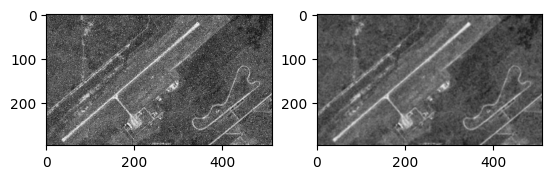

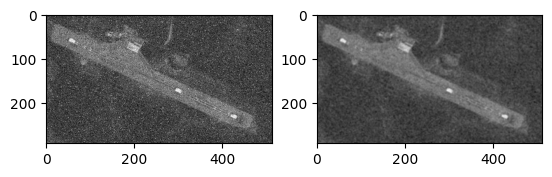

error: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window_w32.cpp:2564: error: (-27:Null pointer) NULL window: 'Canny2' in function 'cvGetTrackbarPos'


error: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window_w32.cpp:2564: error: (-27:Null pointer) NULL window: 'Canny2' in function 'cvGetTrackbarPos'


error: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window_w32.cpp:2564: error: (-27:Null pointer) NULL window: 'Canny2' in function 'cvGetTrackbarPos'


error: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window_w32.cpp:2564: error: (-27:Null pointer) NULL window: 'Canny2' in function 'cvGetTrackbarPos'


error: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window_w32.cpp:2564: error: (-27:Null pointer) NULL window: 'Canny2' in function 'cvGetTrackbarPos'


...

error: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window_w32.cpp:2564: error: (-27:Null pointer) NULL window: 'Canny2' in function 'cvGetTrackbarPos'


error: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window_w32.cpp:2564: error: (-27:Null pointer) NULL window: 'Canny2' in function 'cvGetTrackbarPos'


error: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window_w32.cpp:2564: error: (-27:Null pointer) NULL window: 'Canny2' in function 'cvGetTrackbarPos'


error: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window_w32.cpp:2564: error: (-27:Null pointer) NULL window: 'Canny2' in function 'cvGetTrackbarPos'


error: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window_w32.cpp:2564: error: (-27:Null pointer) NULL window: 'Canny2' in function 'cvGetTrackbarPos'


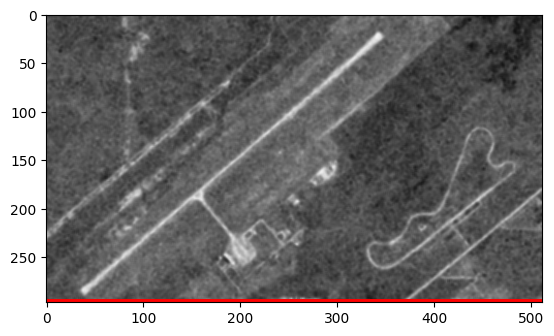

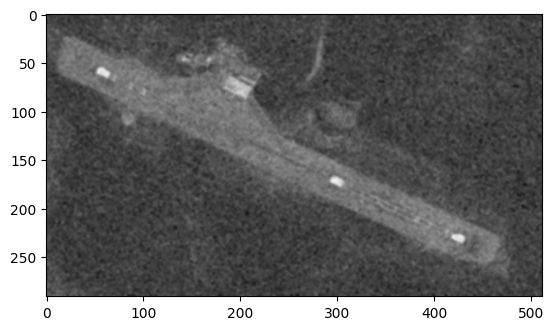

In [6]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import generic_filter

def media_geom_ventana(ventana):
    # Evita log(0) reemplazando ceros por un valor pequeño
    ventana = np.where(ventana == 0, 1e-5, ventana)
    return np.exp(np.mean(np.log(ventana)))

def filtro_media_geom(img, s, t):
    img = img.astype(np.float32)
    # Aplica la función media geométrica a cada ventana s x t
    filtrada = generic_filter(img, media_geom_ventana, size=(s, t), mode='nearest')
    return np.clip(filtrada, 0, 255).astype(np.uint8)

img1 = cv.imread(r'C:\Users\pablo\Desktop\PDI\PDI\Imagenes\corrientes_ruidogris.jpg', cv.IMREAD_GRAYSCALE)
img2 = cv.imread(r'C:\Users\pablo\Desktop\PDI\PDI\Imagenes\iguazu_ruidogris.jpg', cv.IMREAD_GRAYSCALE)

img1_filtro = cv.medianBlur(img1, 3)
img1_filtro = filtro_media_geom(img1_filtro,3,3)
img2_filtro = cv.medianBlur(img2, 3)
img2_filtro = filtro_media_geom(img2_filtro,3,3)

plt.figure(1)
plt.subplot(121)
plt.imshow(img1,cmap='gray', vmin= 0 ,vmax= 255)
plt.subplot(122)
plt.imshow(img1_filtro,cmap='gray', vmin= 0 ,vmax= 255)
plt.figure(2)
plt.subplot(121)
plt.imshow(img2,cmap='gray', vmin= 0 ,vmax= 255)
plt.subplot(122)
plt.imshow(img2_filtro,cmap='gray', vmin= 0 ,vmax= 255)
plt.show()

def func_trackbar(x=None):
    umbralbajo1 = cv.getTrackbarPos('Bajo','Canny1')
    umbralalto1 = cv.getTrackbarPos('Alto','Canny1')
    
    umbralbajo2 = cv.getTrackbarPos('Bajo','Canny2')
    umbralalto2 = cv.getTrackbarPos('Alto','Canny2')
    global bordes1, bordes2
    bordes1 = cv.Canny(img1_filtro,umbralbajo1,umbralalto1,apertureSize=3,L2gradient=True)
    cv.imshow('Canny1', bordes1)
    bordes2 = cv.Canny(img2_filtro,umbralbajo2,umbralalto2,apertureSize=3,L2gradient=True)
    cv.imshow('Canny2', bordes2)

cv.namedWindow('Canny1')
cv.namedWindow('Canny2')

cv.createTrackbar('Bajo', 'Canny1', 0, 500, func_trackbar)
cv.createTrackbar('Alto', 'Canny1', 0, 500, func_trackbar)

cv.createTrackbar('Bajo', 'Canny2', 0, 500, func_trackbar)
cv.createTrackbar('Alto', 'Canny2', 0, 500, func_trackbar)

func_trackbar()
cv.waitKey(0)
cv.destroyAllWindows()

lineas1 = cv.HoughLines(bordes1, 1, np.pi/180, 100)
lineas2 = cv.HoughLines(bordes2, 1, np.pi/180, 100)

img1_filtro = cv.cvtColor(img1_filtro, cv.COLOR_GRAY2RGB)
img2_filtro = cv.cvtColor(img2_filtro, cv.COLOR_GRAY2RGB)

# Encuentra la línea más votada (mayor acumulador) para cada imagen
if lineas1 is not None:
    # En cv.HoughLines, cada línea es [rho, theta], pero no se retorna el valor de votos directamente.
    # Sin embargo, las líneas están ordenadas por votos descendente, así que la primera es la más votada.
    rho, theta = lineas1[0][0]
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a * rho
    y0 = b * rho
    #Convierte los parámetros polares (rho, theta) a coordenadas cartesianas.
    #(x0, y0) es un punto sobre la línea, a una distancia rho del origen, en la dirección theta.
    x1 = int(x0 + 1000 * (-b))
    y1 = int(y0 + 1000 * (a))
    x2 = int(x0 - 1000 * (-b))
    y2 = int(y0 - 1000 * (a))
    cv.line(img1_filtro, (x1, y1), (x2, y2), (255, 0, 0), 2)

if lineas2 is not None:
    # En cv.HoughLines, cada línea es [rho, theta], pero no se retorna el valor de votos directamente.
    # Sin embargo, las líneas están ordenadas por votos descendente, así que la primera es la más votada.
    rho, theta = lineas2[0][0]
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a * rho
    y0 = b * rho
    #Convierte los parámetros polares (rho, theta) a coordenadas cartesianas.
    #(x0, y0) es un punto sobre la línea, a una distancia rho del origen, en la dirección theta.
    x1 = int(x0 + 1000 * (-b))
    y1 = int(y0 + 1000 * (a))
    x2 = int(x0 - 1000 * (-b))
    y2 = int(y0 - 1000 * (a))
    cv.line(img2_filtro, (x1, y1), (x2, y2), (255, 0, 0), 2)

plt.figure(1)
plt.imshow(img1_filtro)
plt.figure(2)
plt.imshow(img2_filtro)
plt.show()


# Guia morfologia ejercicio 2.3


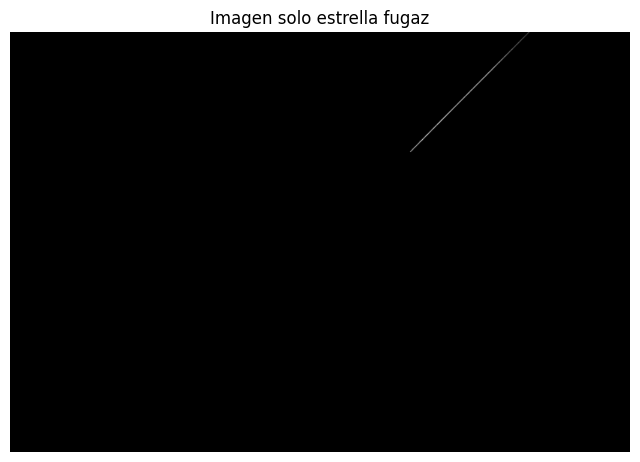

In [3]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

# === 1. Cargar imagen en escala de grises ===
img = cv.imread(r'C:\Users\pablo\Desktop\PDI\PDI\Imagenes\lluviaEstrellas.jpg', cv.IMREAD_GRAYSCALE)

# === 2. Binarizar la imagen ===
_, img = cv.threshold(img, 50, 255, cv.THRESH_BINARY)

# === 3. Definición de kernels ===
kernel = cv.getStructuringElement(cv.MORPH_RECT, (1, 1))
mykernel = np.array([[0,0,0,0,1],
                     [0,0,0,1,0],
                     [0,0,1,0,0],
                     [0,1,0,0,0],
                     [1,0,0,0,0]], dtype=np.uint8)

# === 4. Erosión ===
img = cv.morphologyEx(img, cv.MORPH_ERODE, mykernel)

# === 5. Apertura ===
img_limpia = cv.morphologyEx(img, cv.MORPH_OPEN, kernel)

# === 6. Dilatación ===
kernel = cv.getStructuringElement(cv.MORPH_RECT, (3, 3))
img_limpia = cv.morphologyEx(img_limpia, cv.MORPH_DILATE, kernel)

# === 7. Recargar imagen original ===
img_original = cv.imread(r'C:\Users\pablo\Desktop\PDI\PDI\Imagenes\lluviaEstrellas.jpg', cv.IMREAD_GRAYSCALE)

# === 8. Aplicar máscara ===
img_solo_estrellas = cv.bitwise_and(img_original, img_limpia)

# === 9. Mostrar usando matplotlib ===
plt.figure(figsize=(8, 6))
plt.title("Imagen solo estrella fugaz")
plt.axis("off")
plt.imshow(img_solo_estrellas, cmap='gray')
plt.show()



# Ejercicio 5.1

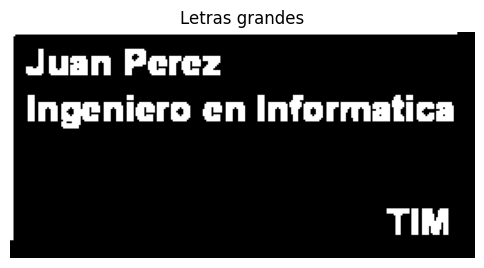

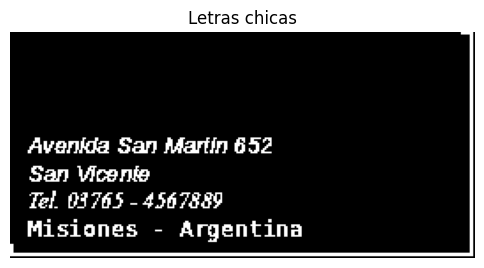

True

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Función para mostrar imágenes en el notebook
def mostrar(imagen, titulo="Imagen", cmap='gray'):
    plt.figure(figsize=(6, 6))
    plt.title(titulo)
    plt.axis("off")
    plt.imshow(imagen, cmap=cmap)
    plt.show()

# === 1. Leer y binarizar la imagen ===
img = cv.imread(r'C:\Users\pablo\Desktop\PDI\PDI\Imagenes\tarjeta.jpeg', cv.IMREAD_GRAYSCALE)
_, img_bin = cv.threshold(img, 210, 255, cv.THRESH_BINARY)
img = cv.bitwise_not(img_bin)

# === 2. Erosión para letras grandes ===
kernel = cv.getStructuringElement(cv.MORPH_CROSS, (3, 3))
img_limpia = cv.morphologyEx(img, cv.MORPH_ERODE, kernel)

# === 3. Dilatación (agrandar letras grandes, se agranda también el ruido) ===
kernel = cv.getStructuringElement(cv.MORPH_RECT, (3, 3))
img_limpia = cv.morphologyEx(img_limpia, cv.MORPH_DILATE, kernel)

# === 4. Invertir la imagen ===
img_limpia = cv.bitwise_not(img_limpia)

# === 5. Aplicar la máscara ===
imagen_solo_chicas = cv.bitwise_and(img, img_limpia)

# === 6. Eliminar contornos grandes con erosiones ===
kernel = cv.getStructuringElement(cv.MORPH_RECT, (1, 2))
kernel2 = cv.getStructuringElement(cv.MORPH_RECT, (2, 1))
imagen_solo_chicas = cv.morphologyEx(imagen_solo_chicas, cv.MORPH_ERODE, kernel)
imagen_solo_chicas = cv.morphologyEx(imagen_solo_chicas, cv.MORPH_ERODE, kernel2)

# === 7. Agrandar las siluetas chicas ===
kernel = cv.getStructuringElement(cv.MORPH_RECT, (17, 17))
imagen_solo_chicas = cv.morphologyEx(imagen_solo_chicas, cv.MORPH_DILATE, kernel)

# === 8. Invertir para usar como máscara ===
imagen_solo_chicas = cv.bitwise_not(imagen_solo_chicas)
img_solo_grandes = cv.bitwise_not(img_limpia)
img_solo_grandes = cv.bitwise_and(imagen_solo_chicas, img_solo_grandes)

# === 9. Mostrar letras grandes ===
mostrar(img_solo_grandes, "Letras grandes")

# === 10. Extraer letras chicas ===
img = cv.imread(r'C:\Users\pablo\Desktop\PDI\PDI\Imagenes\tarjeta.jpeg', cv.IMREAD_GRAYSCALE)
_, img_bin = cv.threshold(img, 210, 255, cv.THRESH_BINARY)
img = cv.bitwise_not(img_bin)

kernel = cv.getStructuringElement(cv.MORPH_RECT, (5, 5))
img_solo_grandes = cv.morphologyEx(img_solo_grandes, cv.MORPH_DILATE, kernel)

img_solo_grandes = cv.bitwise_not(img_solo_grandes)
img_solo_chicas = cv.bitwise_and(img, img_solo_grandes)

# === 11. Mostrar letras chicas ===
mostrar(img_solo_chicas, "Letras chicas")

